<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day08_practice2_CIFAR10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 컬러 이미지 CNN - CIFAR-10

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("장치:", device)
EPOCHS = 10

장치: cuda


In [ ]:
# [셀 1] 데이터 - CIFAR-10
# CIFAR-10 = 컬러 32 × 32 사진 10종 (pickle 배치 형식)

def load_dataset(root="./data"):
  tf = transforms.ToTensor() # uint8 정수(0-255) → float(0-1), (C,H,W)
  tr = datasets.CIFAR10(root=root, train=True, download=True, transform=tf) # 학습 5만장
  te = datasets.CIFAR10(root=root, train=False, download=True, transform=tf) # 테스트 1만장
  return tr, te

train_data, test_data = load_dataset()

100%|██████████| 170M/170M [37:43<00:00, 75.3kB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
이미지 모양: (C=3, H=32, W=32) | 클래스 10개


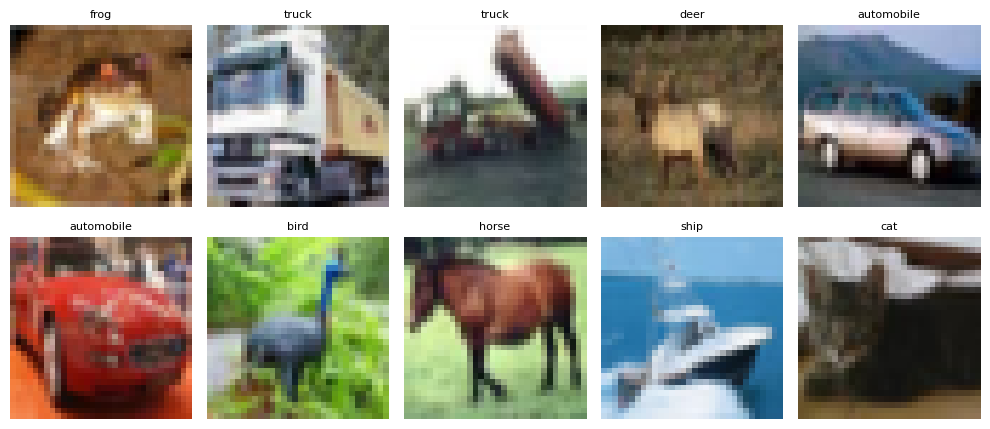

In [ ]:
# 샘플 10장 미리보기
classes = train_data.classes
print(classes) # 클래스 이름 목록
sample, _= train_data[0] # 샘플 한 장 꺼내
C, H, W = sample.shape
print(f"이미지 모양: (C={C}, H={H}, W={W}) | 클래스 {len(classes)}개") # 컬러: 채널 C=(R,G,B), 흑백: 채널 C=1

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
  img, label = train_data[i]
  ax.imshow(img.permute(1, 2, 0) if C == 3 else img[0], cmap=None if C == 3 else "gray") # permute : 컬러면 (C,H,W) → (H,W,C)로 축 재배열
  ax.set_title(classes[label], fontsize=8); ax.axis("off")
plt.tight_layout()
plt.savefig("plot1_samples.png")
plt.show()

In [ ]:
# [셀 2] Normalize - 채널별 표준화
raw = torch.as_tensor(train_data.data).float() / 255.0 # 학습셋 전체 픽셀을 0-1로, ToTensor()가 하던 스케일링
mean = raw.mean(dim=(0,1,2)) # (N,H,W,C) 4차원 → dim=(0,1,2)번 축(N,H,W)을 따라 평균 내서 그 축들을 없애고(접고), 3번 축(C)만 남긴다
std = raw.std(dim=(0,1,2))
print("측정한 채널별 평균", [round(v,3) for v in mean.tolist()],"/표준편차", [round(v,3) for v in std.tolist()])
# mean/std도 '학습 데이터로만' 잰다 - 테스트로 재면 데이터 누수

norm = transforms.Normalize(tuple(mean.tolist()), tuple(std.tolist())) # 측정값으로 정규화 변환 생성
train_tf = transforms.Compose([transforms.ToTensor(), norm]) # ToTensor()(텐서화 + 0~1 스케일) 다음에 norm(표준화) 순서 규칙
test_tf = transforms.Compose([transforms.ToTensor(), norm])
train_data.transform = train_tf # 데이터를 꺼낼 때마다 .transform에 담긴 변환이 알아서 적용
test_data.transform = test_tf

train_loader = DataLoader(train_data, batch_size=128, shuffle=True) # 학습 로더
test_loader = DataLoader(test_data, batch_size=256, shuffle=False) # 테스트로더

측정한 채널별 평균 [0.491, 0.482, 0.447] /표준편차 [0.247, 0.243, 0.262]


In [ ]:
# [셀 3] CNN
class ColorCNN(nn.Module):
  def __init__(self, in_ch, img_size, n_classes):
    super().__init__()
    self.features = nn.Sequential( # 특징 추출부
        nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),
    )
    feat = img_size // 4 # 풀링 2번으로 크기가 1/4, 특징맵 한 변 길이
    self.classifier = nn.Sequential( # 판단부
        nn.Flatten(), # 특징맵으로 1D로
        nn.Linear(64 * feat * feat, 256), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(256, n_classes)
    )
  def forward(self, x):
    return self.classifier(self.features(x))
model = ColorCNN(C, H, len(classes)).to(device)
print("파라미터:", f"{sum(p.numel() for p in model.parameters()):,}개")

loss_fn = nn.CrossEntropyLoss() # 다중 분류 손실
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

파라미터: 1,116,970개


In [ ]:
# [셀 4] 학습 + 평가
for epoch in range(EPOCHS):
  model.train()
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    loss = loss_fn(model(images), labels)
    optimizer.zero_grad(); loss.backward(); optimizer.step()

  model.eval()
  correct = 0
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      correct += (model(images).argmax(1) == labels).sum().item() # 맞은 수 누적, argmax(1)은 가장 높은 점수의 클래스 번호
  print(f"epoch {epoch+1}/{EPOCHS} | 테스트 정확도 {correct/len(test_data):.4f}")

epoch 1/10 | 테스트 정확도 0.5976
epoch 2/10 | 테스트 정확도 0.6701
epoch 3/10 | 테스트 정확도 0.7188
epoch 4/10 | 테스트 정확도 0.7372
epoch 5/10 | 테스트 정확도 0.7612
epoch 6/10 | 테스트 정확도 0.7693
epoch 7/10 | 테스트 정확도 0.7660
epoch 8/10 | 테스트 정확도 0.7666
epoch 9/10 | 테스트 정확도 0.7688
epoch 10/10 | 테스트 정확도 0.7735


In [ ]:
# [셀 5] 클래스별 정확도
n_cls = len(classes)
correct_c = torch.zeros(n_cls) # 클래스별 맞은 수
total_c = torch.zeros(n_cls) # 전체 수 카운터
model.eval()
with torch.no_grad():
  for images, label in test_loader:
    preds = model(images.to(device)).argmax(1).cpu() # 예측 클래스
    for t, p in zip(label, preds):
      total_c[t] += 1
      if t == p: correct_c[t] += 1
print("[클래스별 정확도]")
for i, c in enumerate(classes):
  bar = "█" * int(correct_c[i] / total_c[i] * 20)
  print(f"{c:12s} {correct_c[i]/total_c[i]:.2f} {bar}")

# cat/dog.bird 같은 '비슷한 생김새'기 낮게 나온다 ← 데이터 보강 대상

[클래스별 정확도]
airplane     0.83 ████████████████
automobile   0.88 █████████████████
bird         0.67 █████████████
cat          0.63 ████████████
deer         0.73 ██████████████
dog          0.62 ████████████
frog         0.81 ████████████████
horse        0.81 ████████████████
ship         0.87 █████████████████
truck        0.88 █████████████████
